In [7]:
import pandas as pd
import os
import sys
from cycler import cycler
import argparse
from functools import reduce

workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../")

import pyanalib.pandas_helpers as ph
import warnings
from pyanalib.split_df_helpers import *
from makedf.util import *
from analysis_village.gump.gump_cuts import *
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

In [8]:
def crossing_cut(df):
    return (np.sign(df.slc_vtx_x) == np.sign(df.mu_end_x)) & (np.sign(df.slc_vtx_x) == np.sign(df.p_end_x))
    #return ((df.mu_phi < -50.) & (df.mu_phi > -120.) & (np.abs(df.slc_vtx_x) > 200.)) |\
    #        ((df.mu_phi > 50.) & (df.mu_phi < 120.) & (np.abs(df.slc_vtx_x) > 200.)) |\
    #        ((df.mu_phi > -50.) & (df.mu_phi < 50.)) | (df.mu_phi < -120.) | (df.mu_phi > 120.)
    # return ((df.mu_phi > -50.) & (df.mu_phi < 50.)) | (df.mu_phi < -120.) | (df.mu_phi > 120.)

def bin_centers(b):
    return 0.5 * (b[:-1] + b[1:])

In [9]:
prefix = "/exp/sbnd/data/users/nrowe/GUMP/SBND_SpringBNBOffData/"
dfs = []

for i in range(400):
    all_dfs = load_dfs(prefix+f"SBND_SpringBNBOffData_{i}.df", ['evt', 'hdr'])
    recodf = all_dfs['evt']
    hdrdf = all_dfs['hdr']

    # Keeps all hdrdf rows, can't be slices with out header
    merged = recodf.reset_index().merge(
        hdrdf.reset_index(),
        on=['__ntuple', 'entry'],
        how='right'  
    )

    # when we have a header without a slice, give it an index to preserve header info
    merged['rec.slc..index'] = merged['rec.slc..index'].fillna(0) 

    mergeddf = merged.set_index(['__ntuple', 'entry', 'rec.slc..index']) # use this for matching common truth to reco
    dfs.append(mergeddf)

data_df = pd.concat(dfs)

In [10]:
prefix = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/"
dfs = []

for i in range(5):
    all_dfs = load_dfs(f"/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/SBND_SpringMC_rewgt_5_{i}.df", ['evt', 'hdr'])
    recodf = all_dfs['evt']
    hdrdf = all_dfs['hdr']


    # Keeps all hdrdf rows, can't be slices with out header
    merged = recodf.reset_index().merge(
        hdrdf.reset_index(),
        on=['__ntuple', 'entry'],
        how='right'  
    )

    # when we have a header without a slice, give it an index to preserve header info
    merged['rec.slc..index'] = merged['rec.slc..index'].fillna(0) 

    mergeddf = merged.set_index(['__ntuple', 'entry', 'rec.slc..index']) # use this for matching common truth to reco
    dfs.append(mergeddf[(mergeddf.true_pdg == -1)])

recodf = pd.concat(dfs)

In [11]:
extravarnames = [
    "mu_costh",
    "mu_phi",
    "p_costh",
    "p_phi",
]

extravars = [
    lambda d: np.cos(d.mu_dir_z),
    lambda d: np.arctan2(d.mu_dir_x, d.mu_dir_y)*180/np.pi,
    lambda d: np.cos(d.p_dir_z),
    lambda d: np.arctan2(d.p_dir_x, d.p_dir_y)*180/np.pi,
]

for v, vname in zip(extravars, extravarnames):
    data_df[vname] = v(data_df)
    recodf[vname] = v(recodf)

int_c = list(set(recodf) & set(data_df))
int_c.remove('nu_E_calo')
int_c.remove('detector')
int_c.remove('tmatch_idx')
int_c.remove('baseline')
int_c.remove('other_shw_length')
int_c.remove('other_trk_length')
int_c.remove('crthit')
int_c.remove('is_clear_cosmic')

to_drop = []
for c in int_c:
    if 'stub' in c:
        to_drop.append(c)
    elif 'true' in c:
        to_drop.append(c)

for d in to_drop:
    int_c.remove(d)

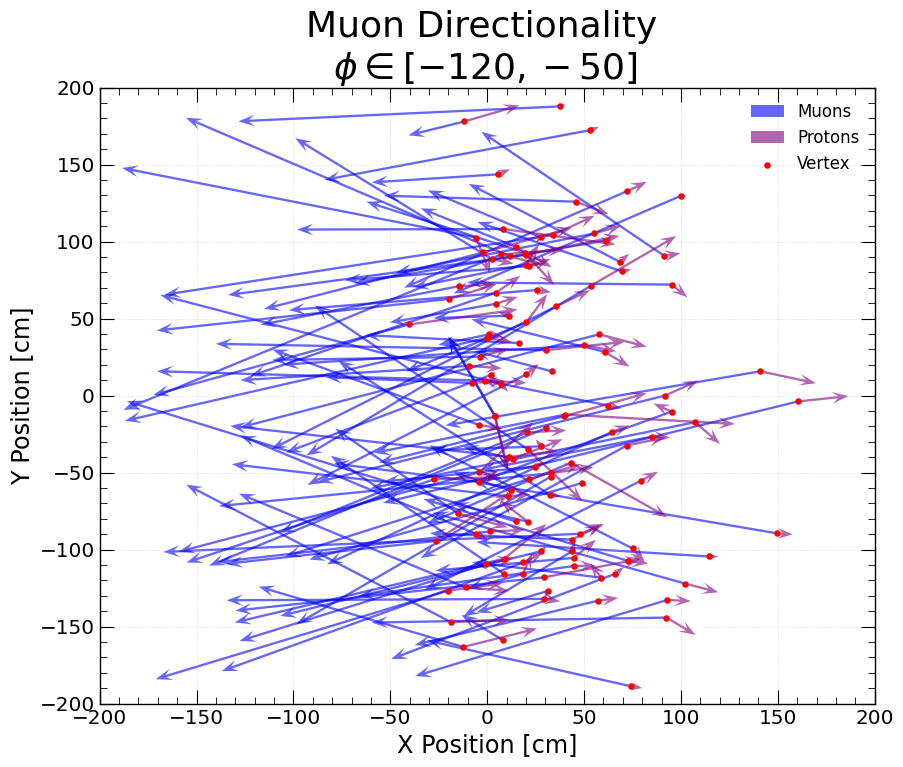

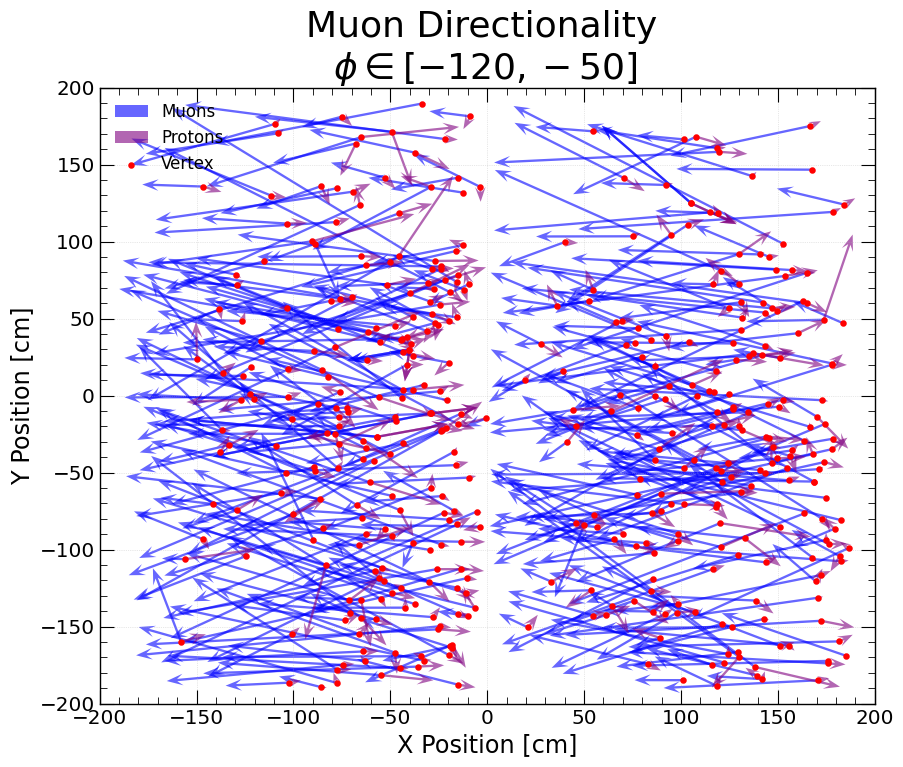

1
1
1
1
1


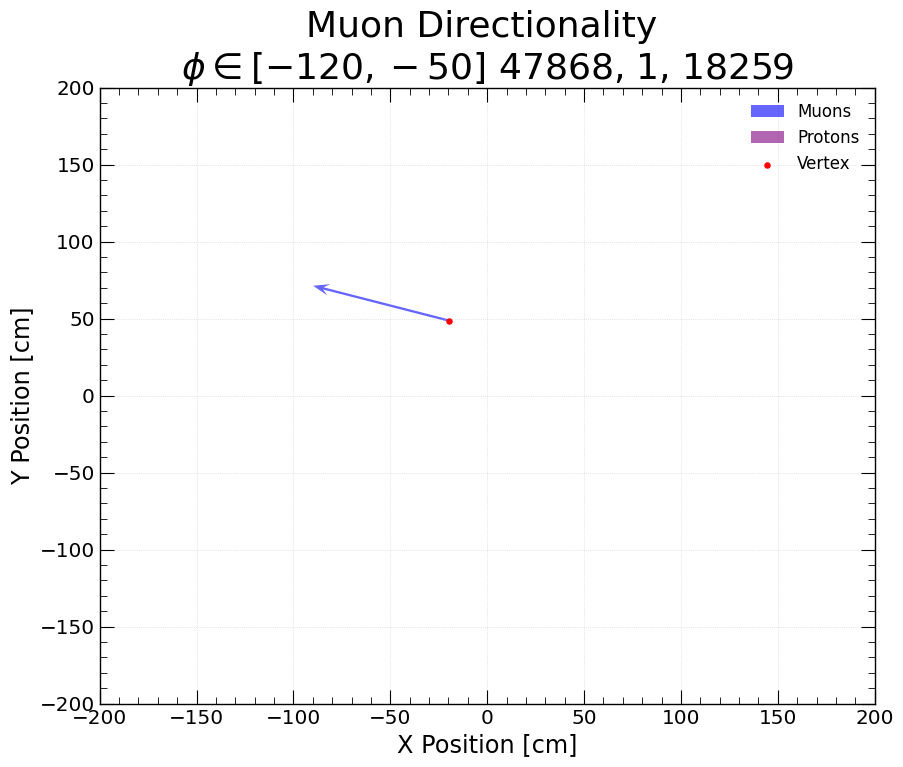

1
1
1


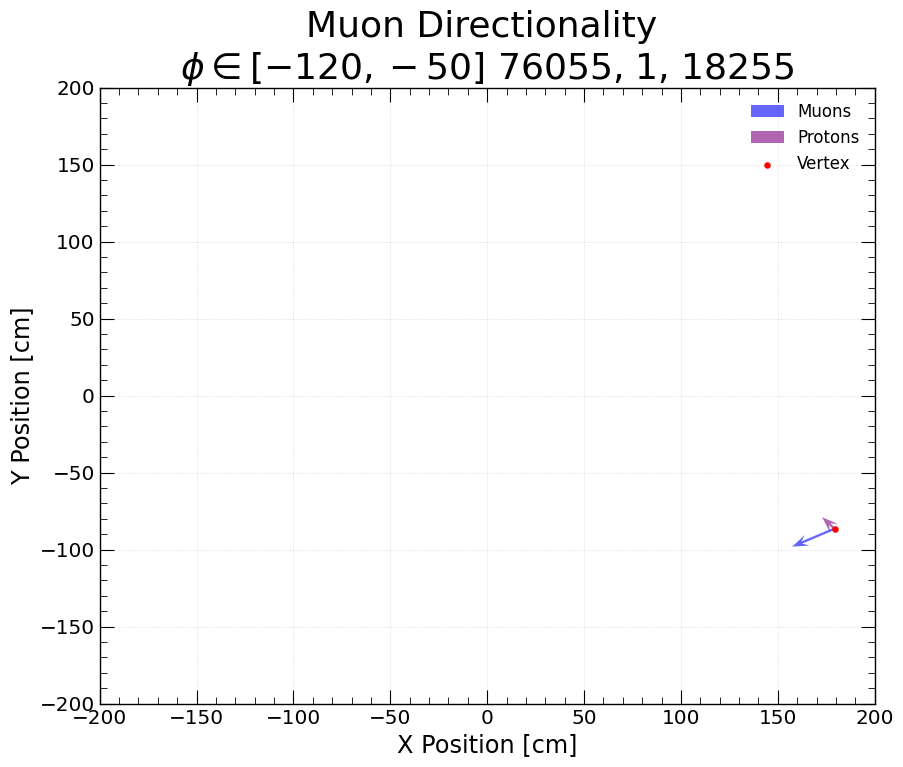

1
1
1
1
1
2
1


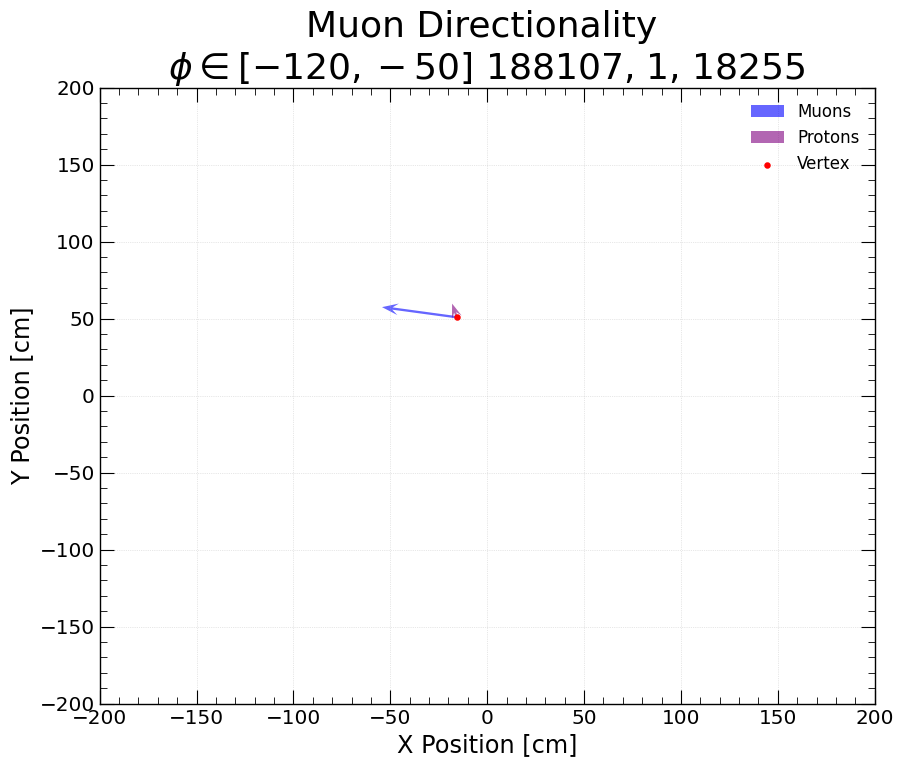

1
1
1
1
1
1
1


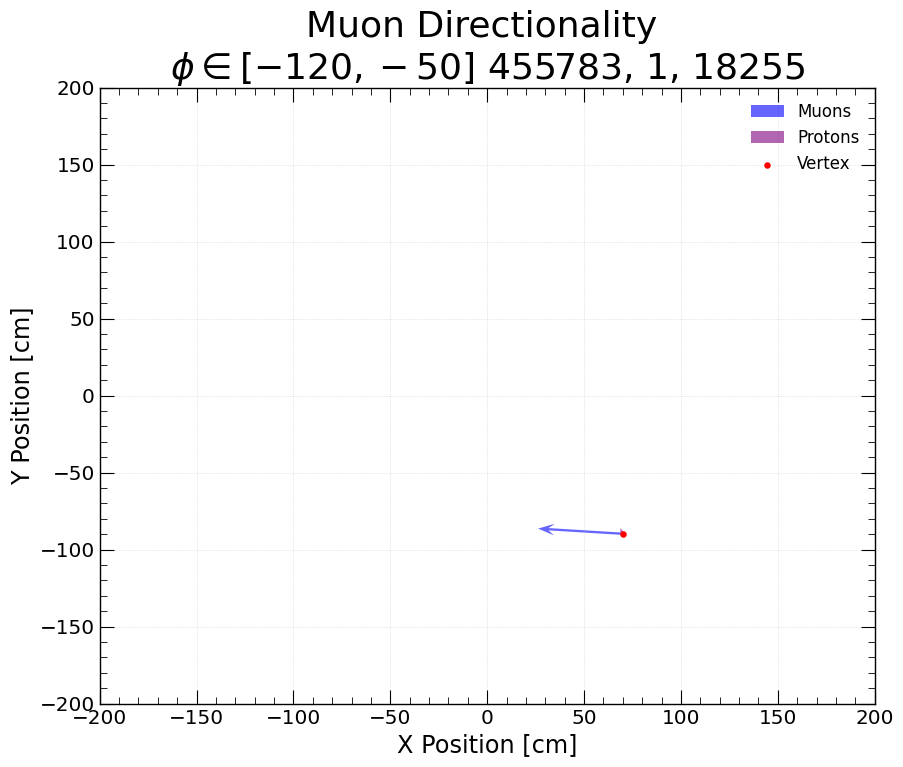

1
1
1
1
1


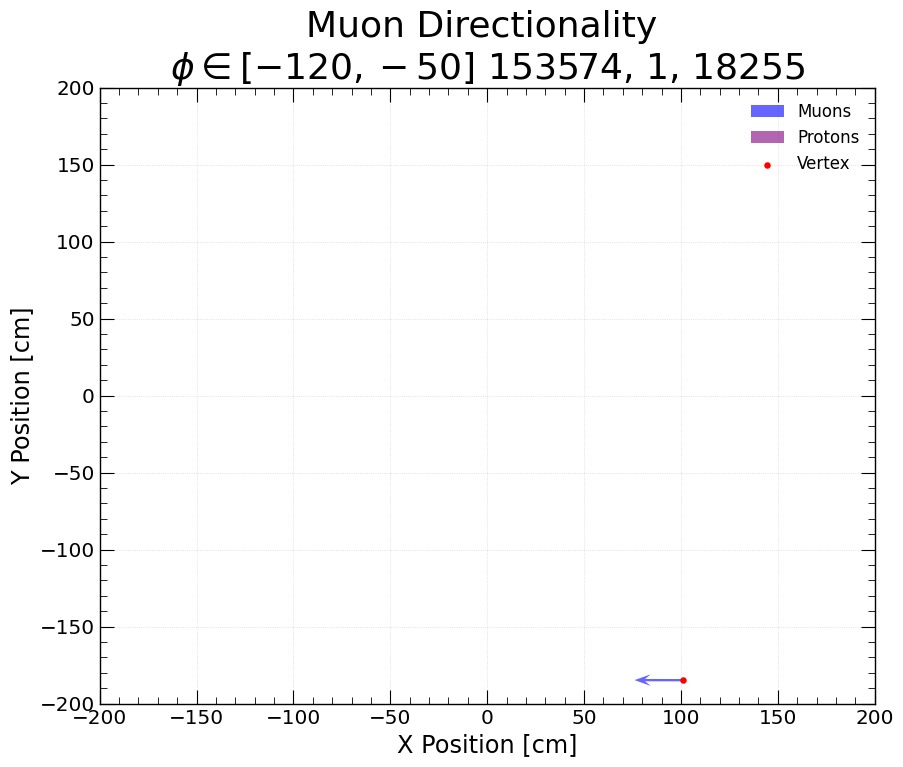

1
1
1
1


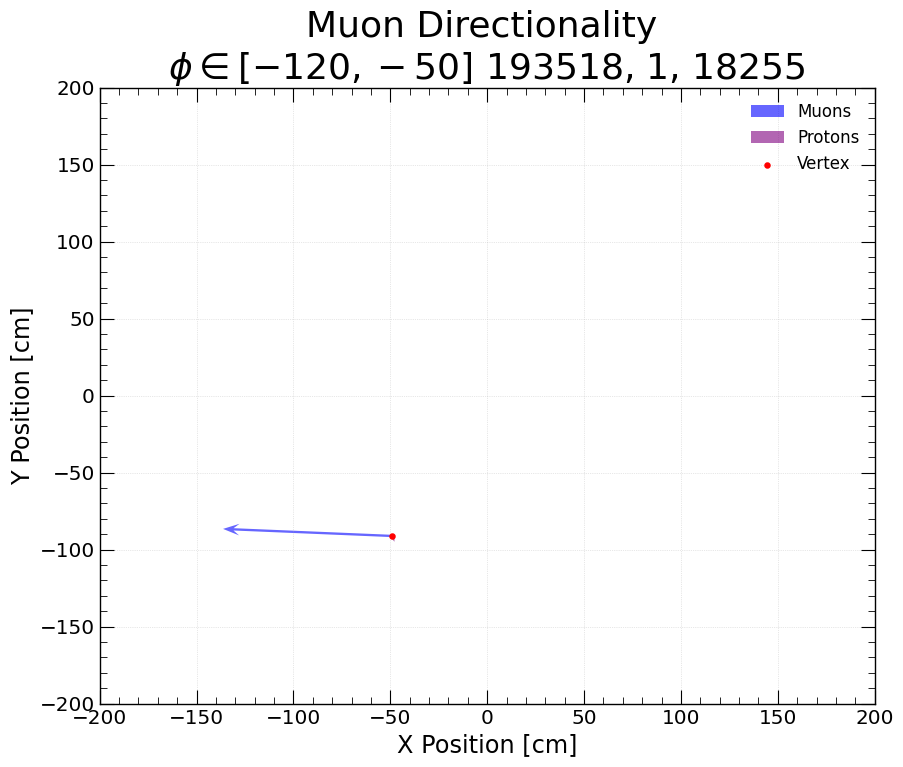

1
1


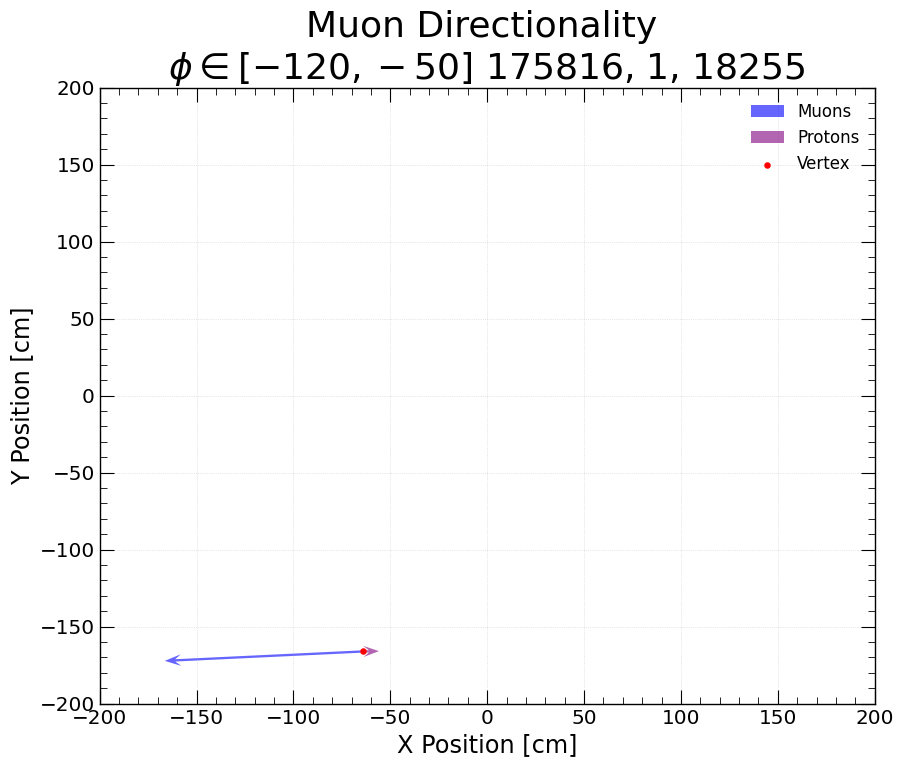

1
1


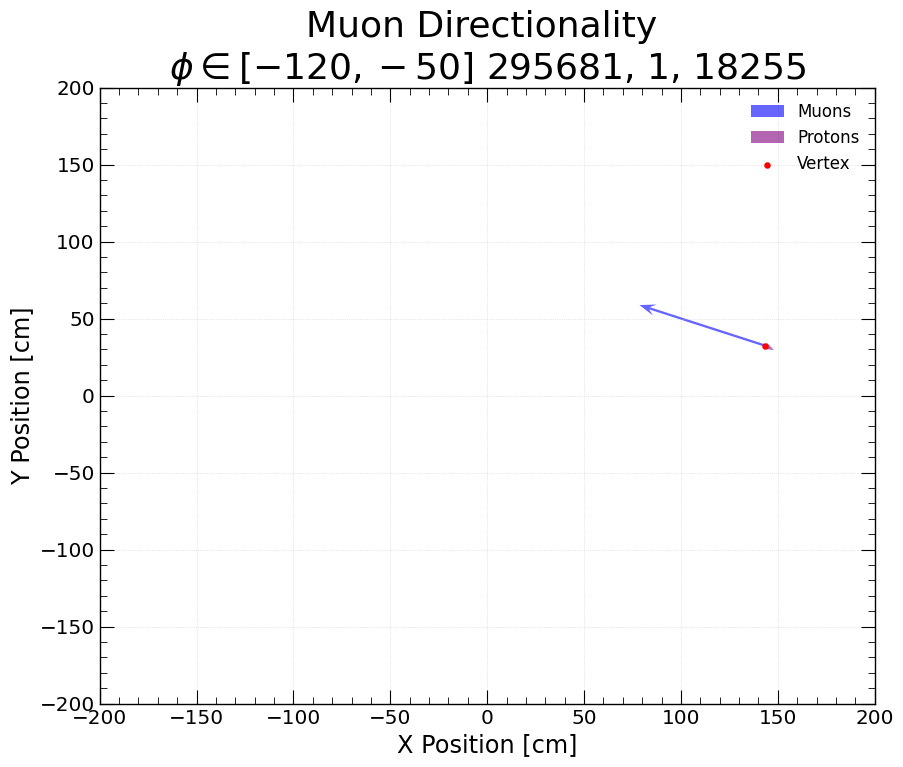

1
1
1
1
1


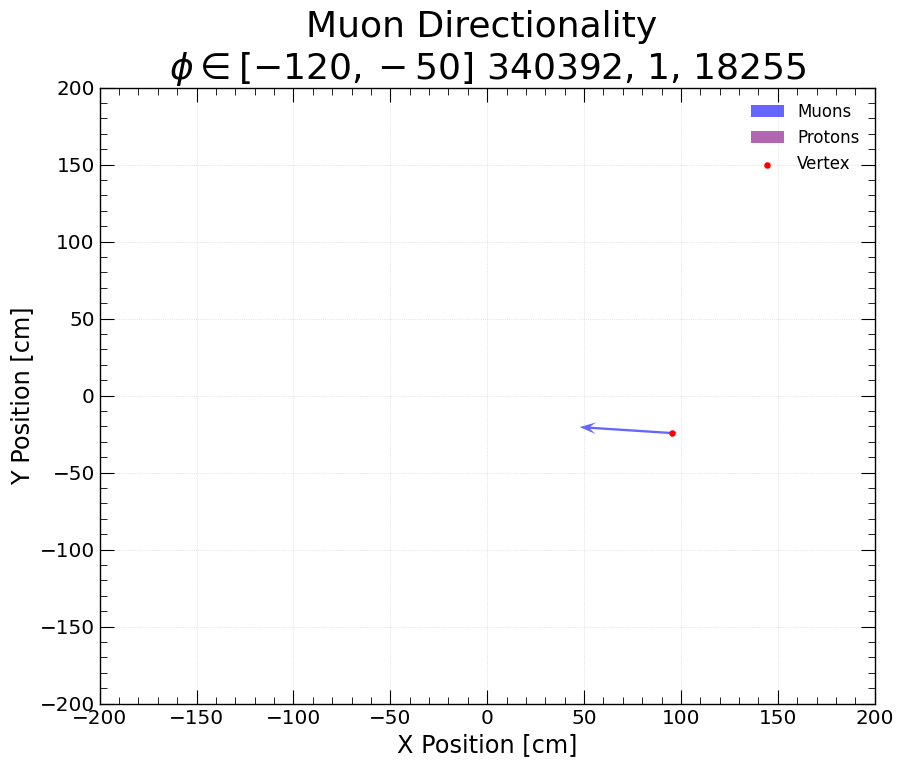

1
1


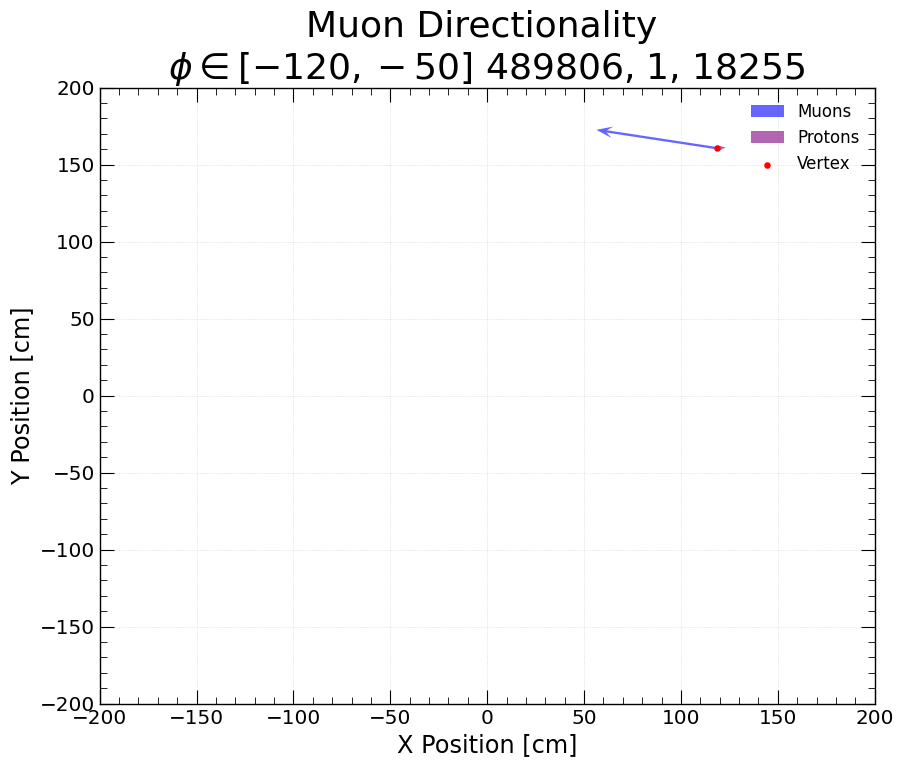

1
1
1
1


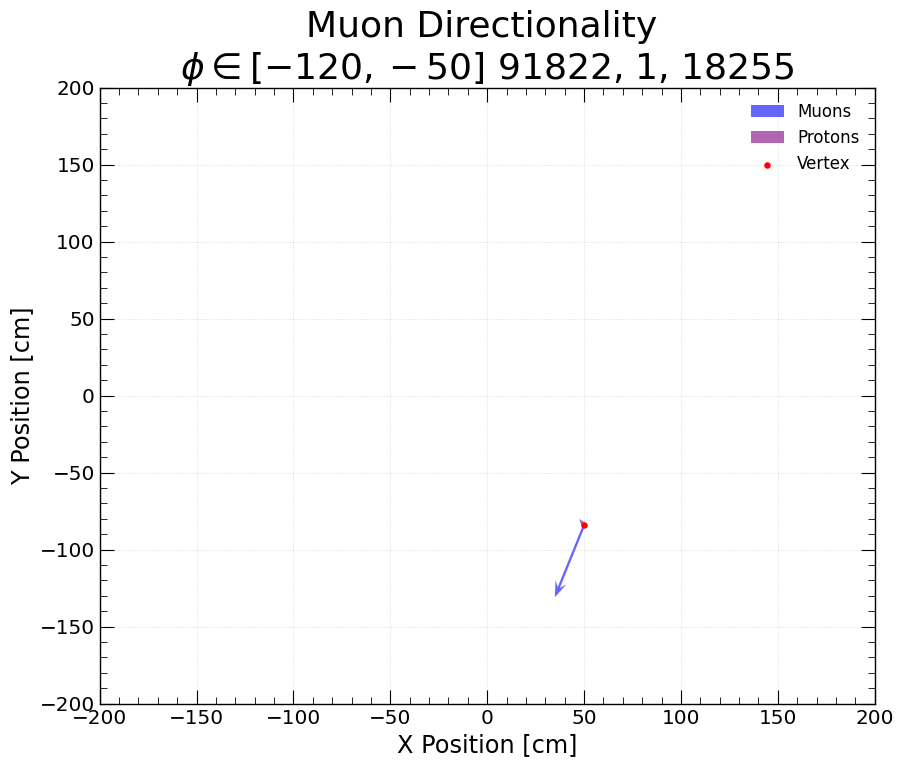

1
1
1
1


In [54]:
plot_arrows(data_df[~crossing_cut(data_df)])
plot_arrows(data_df[crossing_cut(data_df)])

pass_df = data_df[crossing_cut(data_df)]
fail_df = data_df[~crossing_cut(data_df)]

valid_df = pass_df[['run', 'subrun', 'evt']].dropna().drop_duplicates()
df = data_df.copy()
df = df.reset_index().merge(valid_df, on=['run', 'subrun', 'evt'], how='inner').set_index(df.index.names)  
for i in range(50):
    plot_arrows(df[evt_cut(df, df.iloc[i].evt, df.iloc[i].subrun, df.iloc[i].run)], mask_bool=True, title_str=f"{df.iloc[i].evt}, {df.iloc[i].subrun}, {df.iloc[i].run}")

In [1]:
#recodf_new = recodf[(recodf.mu_phi < -50.) & (recodf.mu_phi > -120.)]
#data_df_new = data_df[(data_df.mu_phi < -50.) & (data_df.mu_phi > -120.)]
recodf_new = recodf
data_df_new = data_df

#recodf_new = recodf[crossing_cut(recodf)]
#data_df_new = data_df[crossing_cut(data_df)]

recodf_new = recodf_new[(recodf_new.mu_phi < -50.) & (recodf_new.mu_phi > -120.)]
data_df_new = data_df_new[(data_df_new.mu_phi < -50.) & (data_df_new.mu_phi > -120.)]

b = np.linspace(-200., 200., 20)
for var, c in zip(['mu_end_x', 'p_end_x', 'slc_vtx_x'], ['tab:blue', 'tab:orange', 'black']):
    plt.hist(recodf_new[var], bins=b, weights=np.ones_like(recodf_new[var])/len(recodf_new), color=c, histtype='step', label=f'mc {var}')
    n, _ = np.histogram(data_df_new[var], bins=b, weights=np.ones_like(data_df_new[var])/len(data_df_new))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color=c, label=f'data {var}')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df_new))/len(data_df_new), color=c, linestyle='none')
plt.title(f'SBND true_pdg == -1 \n(OffBeam Light Data, BNBLight MC) \n$\phi \in [-120, -50]$')
plt.legend()
plt.ylim(0., 0.2)
plt.ylabel("Events (Area Norm.)")
plt.xlabel('Endpoint Location')
plt.show()
plt.clf()

NameError: name 'recodf' is not defined

slc_vtx_x


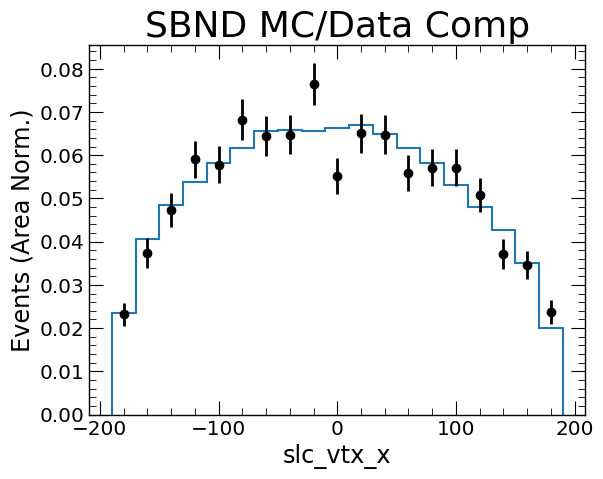

slc_vtx_y


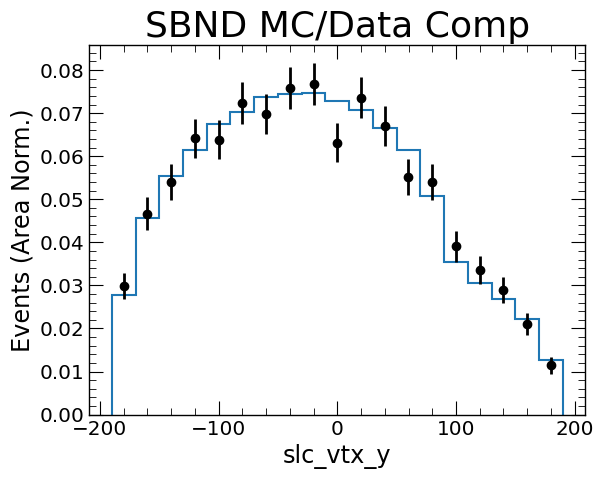

slc_vtx_z


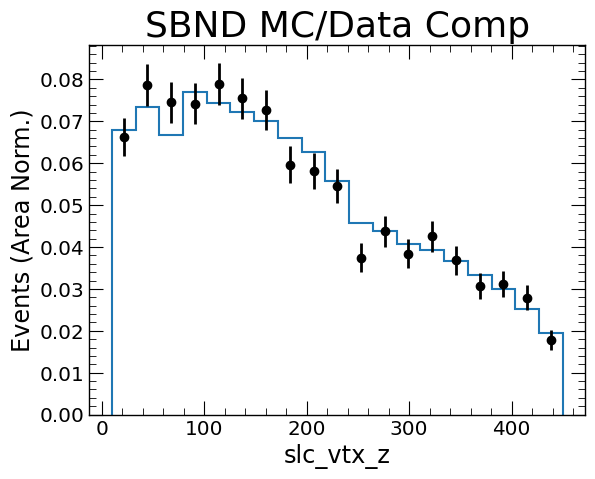

mu_phi


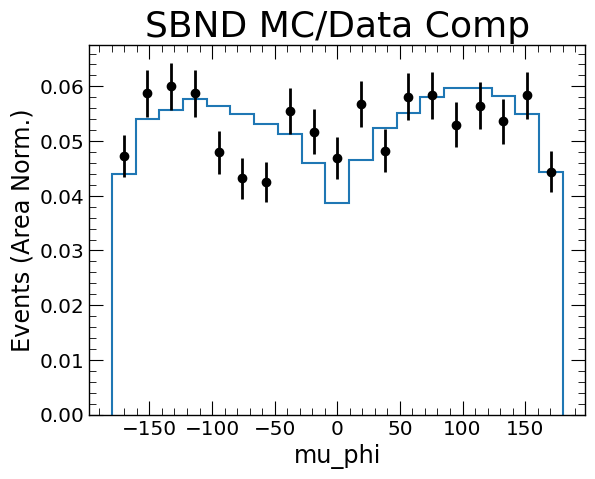

mu_end_x


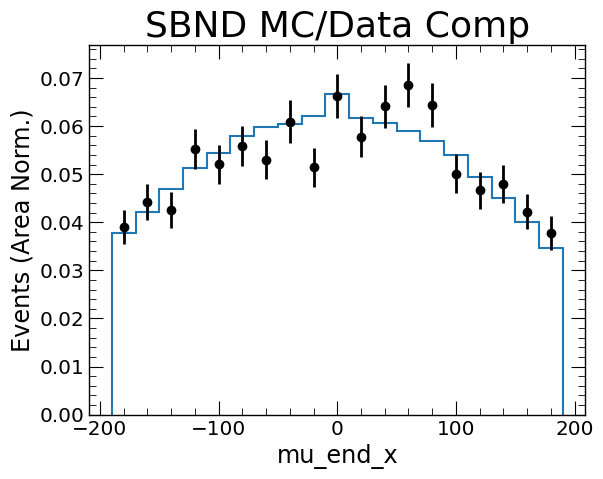

p_phi


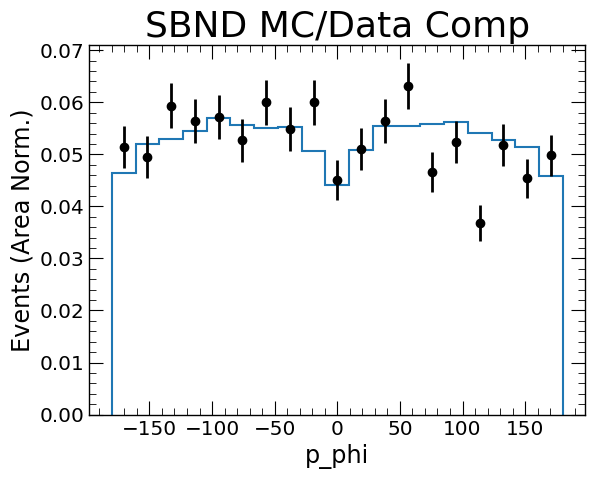

p_end_x


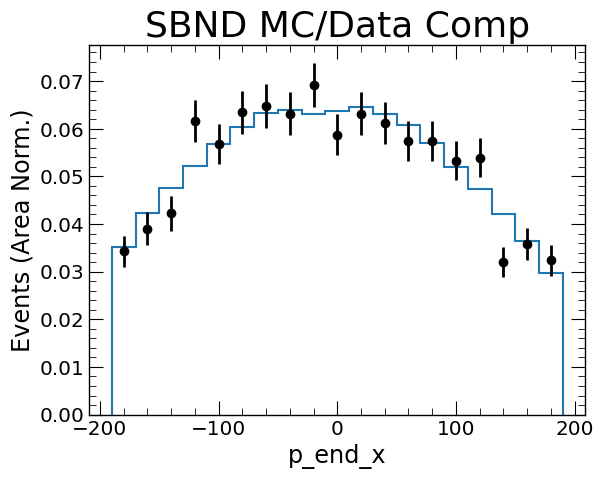

p_len


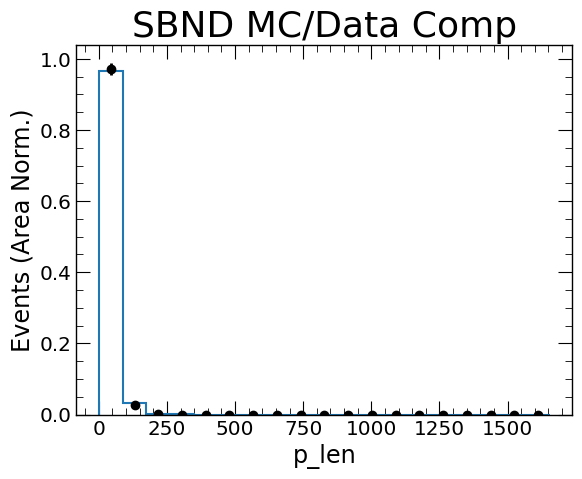

<Figure size 640x480 with 0 Axes>

In [11]:
to_plot = ['mu_phi']

for var in to_plot:
    print(var)
    b = np.linspace(min(recodf[var]), max(recodf[var]), 20)
    plt.hist(recodf[var], bins=b, weights=np.ones_like(recodf[var])/len(recodf), histtype='step', label='mc')
    n, _ = np.histogram(data_df[var], bins=b, weights=np.ones_like(data_df[var])/len(data_df))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color='black', label='data abs norm')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df))/len(data_df), color='black', linestyle='none')
    plt.title('SBND MC/Data Comp')
    plt.ylabel("Events (Area Norm.)")
    plt.xlabel(var)
    plt.show()
    plt.clf()

slc_vtx_x


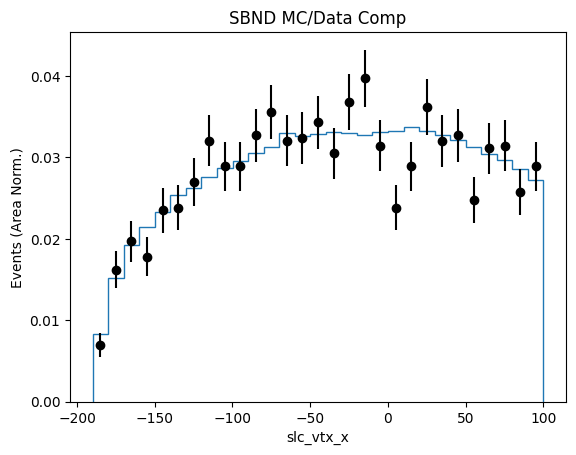

slc_vtx_x


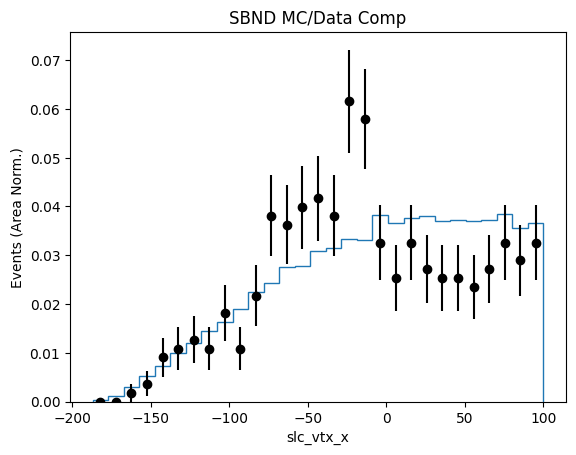

<Figure size 640x480 with 0 Axes>

In [5]:
recodf_new = recodf[(recodf.mu_phi < -50.) & (recodf.mu_phi > -120.)]
data_df_new = data_df[(data_df.mu_phi < -50.) & (data_df.mu_phi > -120.)]

to_plot = ['slc_vtx_x']

for var in to_plot:
    print(var)
    b = np.linspace(min(recodf[var]), 100., 30)
    plt.hist(recodf[var], bins=b, weights=np.ones_like(recodf[var])/len(recodf), histtype='step', label='mc')
    n, _ = np.histogram(data_df[var], bins=b, weights=np.ones_like(data_df[var])/len(data_df))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color='black', label='data abs norm')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df))/len(data_df), color='black', linestyle='none')
    plt.title('SBND MC/Data Comp')
    plt.ylabel("Events (Area Norm.)")
    plt.xlabel(var)
    plt.show()
    plt.clf()
    
for var in to_plot:
    print(var)
    b = np.linspace(min(recodf_new[var]), 100., 30)
    plt.hist(recodf_new[var], bins=b, weights=np.ones_like(recodf_new[var])/len(recodf_new), histtype='step', label='mc')
    n, _ = np.histogram(data_df_new[var], bins=b, weights=np.ones_like(data_df_new[var])/len(data_df_new))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color='black', label='data abs norm')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df_new))/len(data_df_new), color='black', linestyle='none')
    plt.title('SBND MC/Data Comp')
    plt.ylabel("Events (Area Norm.)")
    plt.xlabel(var)
    plt.show()
    plt.clf()

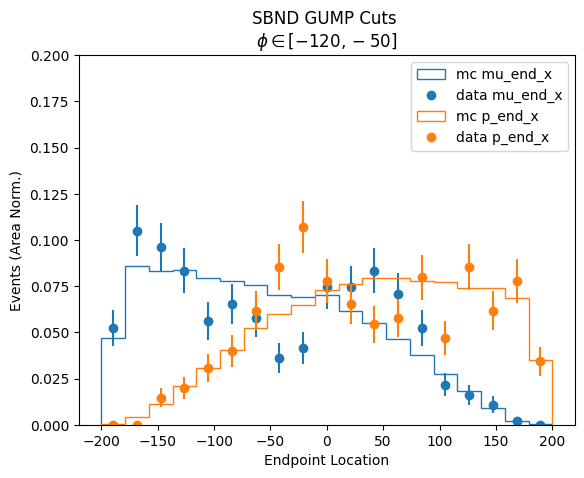

<Figure size 640x480 with 0 Axes>

In [6]:
recodf_new = recodf[(recodf.mu_phi < -50.) & (recodf.mu_phi > -120.)]
data_df_new = data_df[(data_df.mu_phi < -50.) & (data_df.mu_phi > -120.)]

b = np.linspace(-200., 200., 20)
for var, c in zip(['mu_end_x', 'p_end_x'], ['tab:blue', 'tab:orange']):
    plt.hist(recodf_new[var], bins=b, weights=np.ones_like(recodf_new[var])/len(recodf_new), color=c, histtype='step', label=f'mc {var}')
    n, _ = np.histogram(data_df_new[var], bins=b, weights=np.ones_like(data_df_new[var])/len(data_df_new))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color=c, label=f'data {var}')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df_new))/len(data_df_new), color=c, linestyle='none')
plt.title(f'SBND GUMP Cuts \n$\phi \in [-120, -50]$')
plt.legend()
plt.ylim(0., 0.2)
plt.ylabel("Events (Area Norm.)")
plt.xlabel('Endpoint Location')
plt.show()
plt.clf()

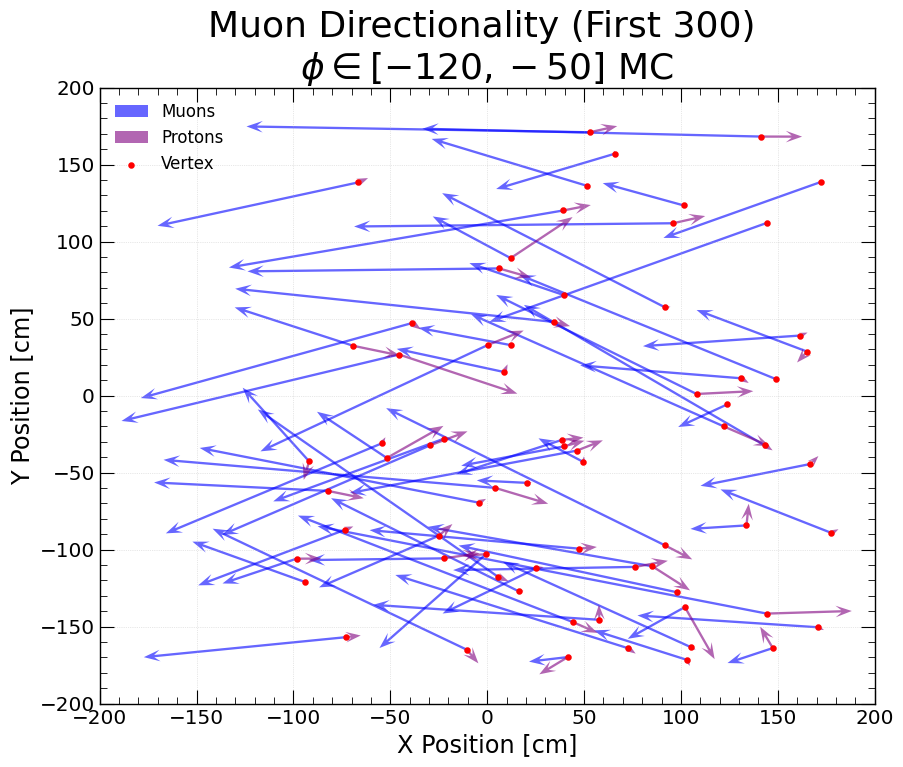

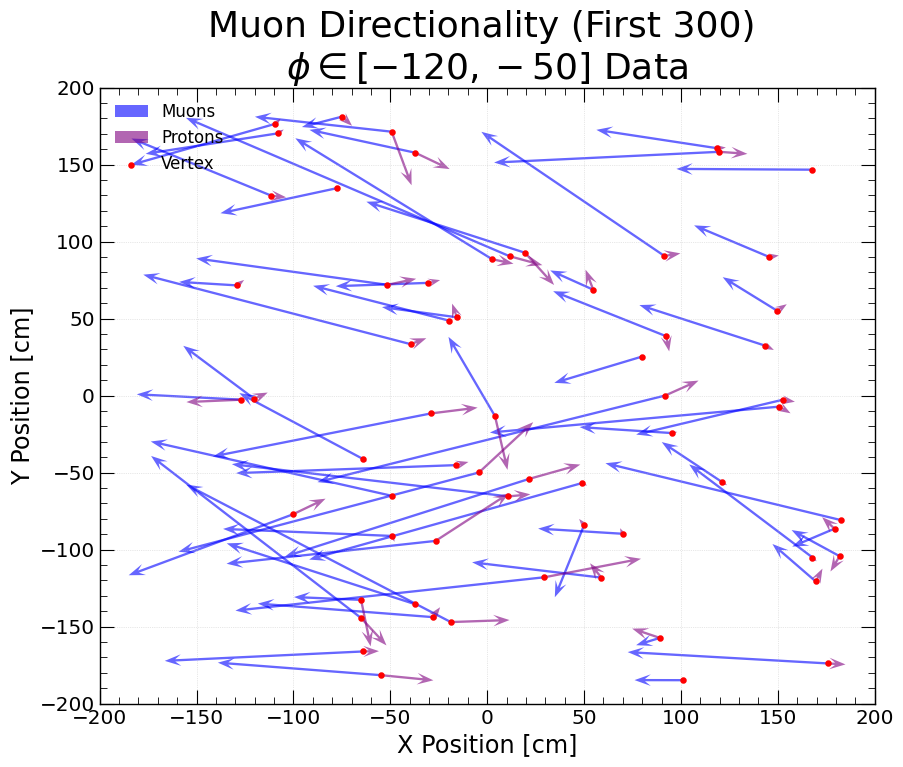

In [51]:
def plot_arrows(df, n=None, mask_bool=True, title_str=''):
    """
    Plots muon trajectories as arrows to show direction.
    """
    # Filter for phi range and limit to 100
    if n:
        df = df.head(n)
    mask = (df['mu_phi'] > -120) & (df['mu_phi'] < -50)

    if mask_bool:
        df_sub = df[mask]
    else:
        df_sub = df

    if len(df_sub) > 0:
        plt.figure(figsize=(10, 8))
        
        # Calculate displacement vectors
        mu_dx = df_sub['mu_end_x'] - df_sub['slc_vtx_x']
        mu_dy = df_sub['mu_end_y'] - df_sub['slc_vtx_y']
        
        p_dx = df_sub['p_end_x'] - df_sub['slc_vtx_x']
        p_dy = df_sub['p_end_y'] - df_sub['slc_vtx_y']
        
        # quiver(x_start, y_start, dx, dy)
        # angles='xy', scale_units='xy', scale=1 ensures the arrows 
        # point exactly to the end coordinates.
        mu_q = plt.quiver(df_sub['slc_vtx_x'], df_sub['slc_vtx_y'], mu_dx, mu_dy, 
                       color='blue', alpha=0.6, 
                       angles='xy', scale_units='xy', scale=1,
                       width=0.003, headwidth=5, headlength=7, label='Muons')
    
        p_q = plt.quiver(df_sub['slc_vtx_x'], df_sub['slc_vtx_y'], p_dx, p_dy, 
                       color='purple', alpha=0.6, 
                       angles='xy', scale_units='xy', scale=1,
                       width=0.003, headwidth=5, headlength=7, label='Protons')
        
        # Optional: Scatter the vertex points for clarity
        plt.scatter(df_sub['slc_vtx_x'], df_sub['slc_vtx_y'], 
                    color='red', s=10, label='Vertex', zorder=3)
    
        plt.xlim(-200., 200.)
        plt.ylim(-200., 200.)
        plt.xlabel('X Position [cm]')
        plt.ylabel('Y Position [cm]')
        first_str=''
        if n:
            first_str = f"(First {n}) "
        if mask_bool:
            plt.title(f'Muon Directionality {first_str}\n$\phi \in [-120, -50]$ '+title_str)
        else:
            plt.title(f'Muon Directionality {first_str}'+title_str)
            
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
    
plot_arrows(recodf, 300, title_str='MC')
plot_arrows(data_df, 300, title_str='Data')

slc_vtx_x


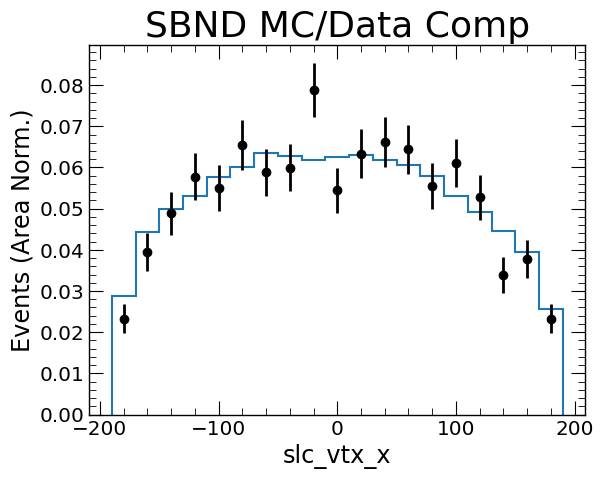

mu_phi


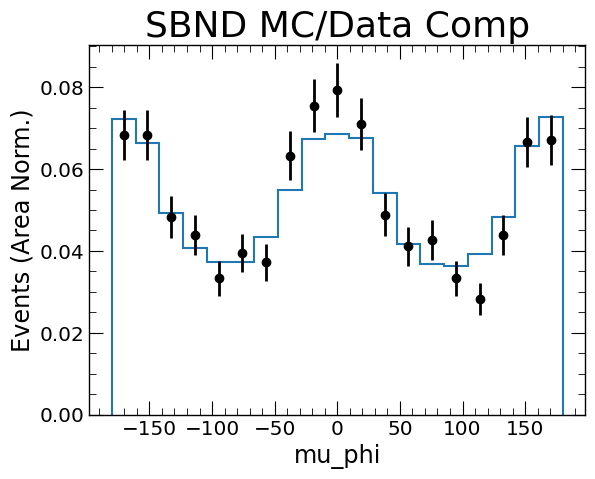

mu_end_x


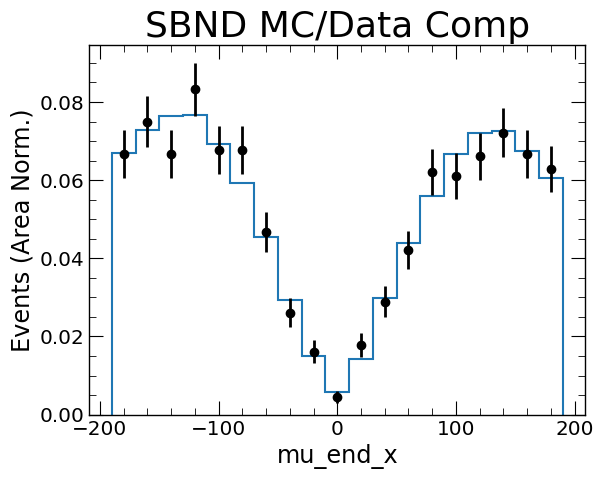

<Figure size 640x480 with 0 Axes>

In [110]:
to_plot = ['slc_vtx_x', 'mu_phi', 'mu_end_x']

for var in to_plot:
    print(var)
    b = np.linspace(min(recodf_new[var]), max(recodf_new[var]), 20)
    plt.hist(recodf_new[var], bins=b, weights=np.ones_like(recodf_new[var])/len(recodf_new), histtype='step', label='mc')
    n, _ = np.histogram(data_df_new[var], bins=b, weights=np.ones_like(data_df_new[var])/len(data_df_new))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color='black', label='data abs norm')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df_new))/len(data_df_new), color='black', linestyle='none')
    plt.title('SBND MC/Data Comp')
    plt.ylabel("Events (Area Norm.)")
    plt.xlabel(var)
    plt.show()
    plt.clf()

0.533509851793267


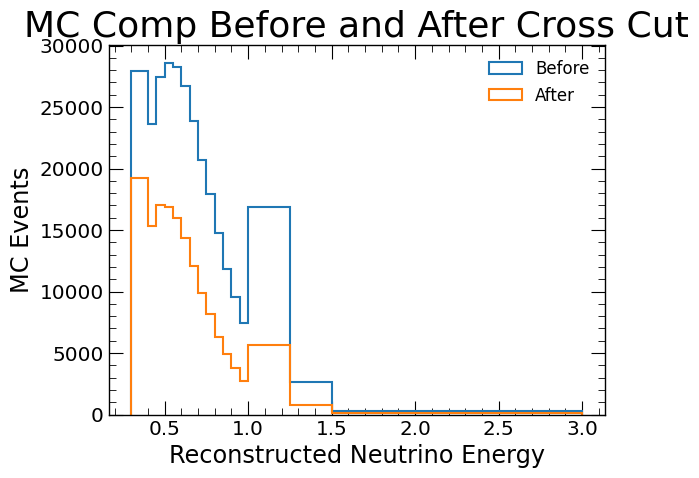

In [112]:
b_E = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 3.0])
plt.hist(recodf.nu_E_calo, bins=b_E, histtype='step', label="Before")
plt.hist(recodf_new.nu_E_calo, bins=b_E, histtype='step', label="After")
plt.title("MC Comp Before and After Cross Cut")
plt.legend()
plt.ylabel("MC Events")
plt.xlabel("Reconstructed Neutrino Energy")
print(len(recodf_new.nu_E_calo)/len(recodf.nu_E_calo))

slc_vtx_x


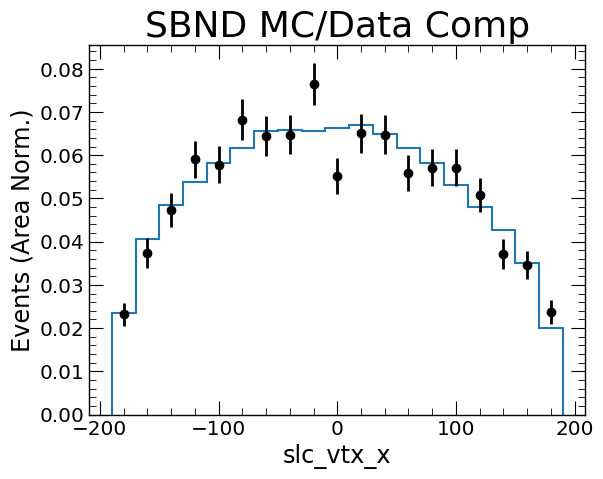

mu_phi


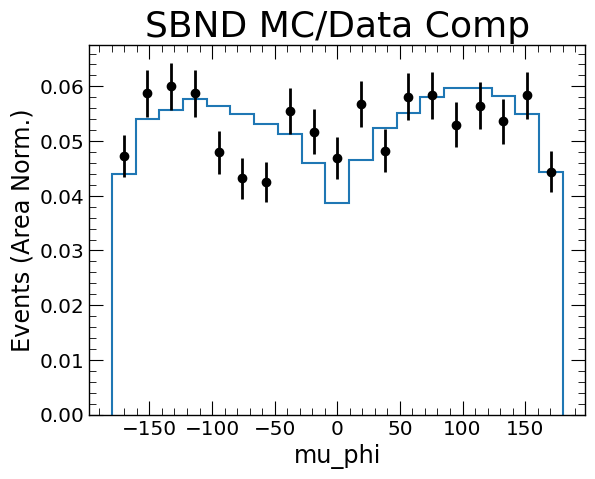

slc_vtx_x


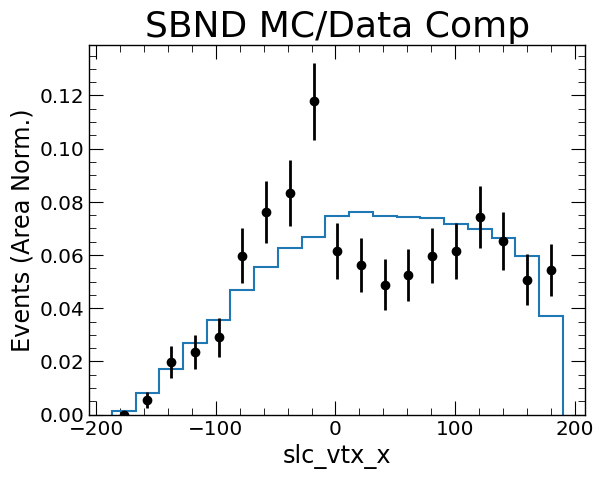

mu_phi


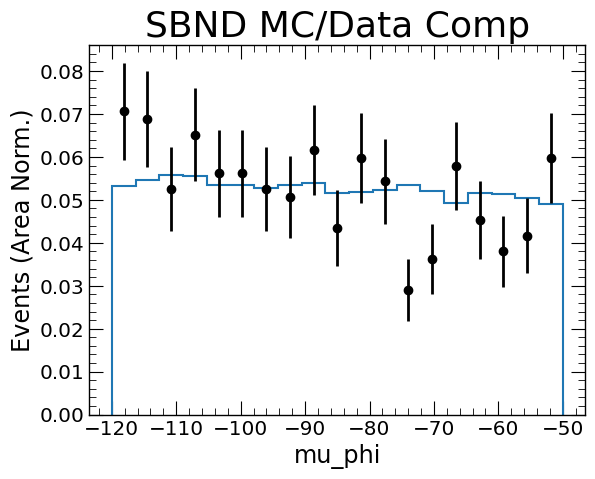

slc_vtx_x


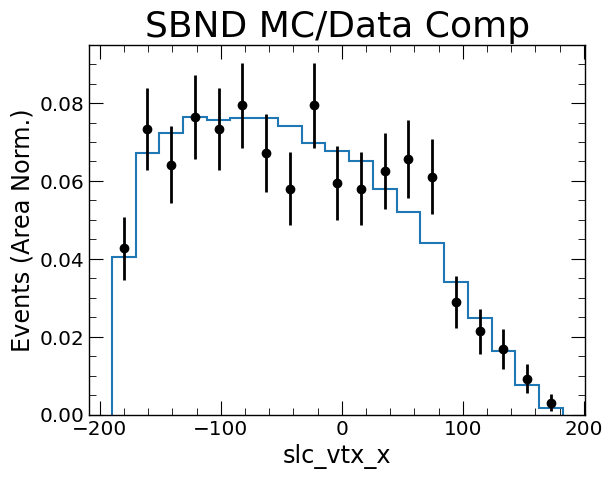

mu_phi


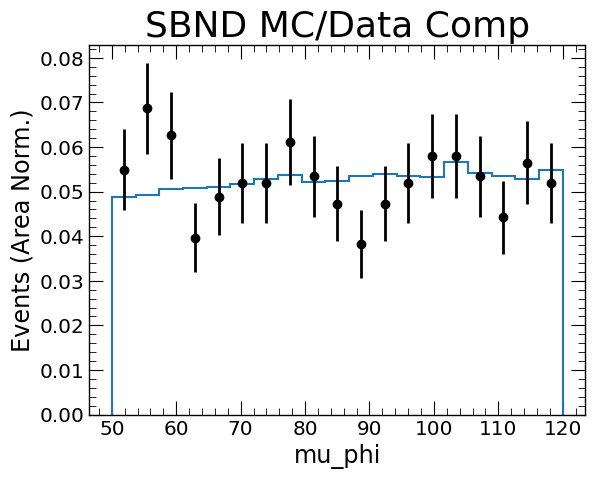

<Figure size 640x480 with 0 Axes>

In [55]:
for i, c in enumerate([[-120.0, -50.0],[50.0, 120.0]]):
    recodf_temp = recodf[(recodf.mu_phi < c[1]) & (recodf.mu_phi > c[0])]
    data_df_temp = data_df[(data_df.mu_phi < c[1]) & (data_df.mu_phi > c[0])]

    for var in to_plot:
        print(var)
        b = np.linspace(min(recodf_temp[var]), max(recodf_temp[var]), 20)
        plt.hist(recodf_temp[var], bins=b, weights=np.ones_like(recodf_temp[var])/len(recodf_temp), histtype='step', label='mc')
        n, _ = np.histogram(data_df_temp[var], bins=b, weights=np.ones_like(data_df_temp[var])/len(data_df_temp))
        plt.plot(bin_centers(b), n, marker='o', linestyle='none', color='black', label='data abs norm')
        plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df_temp))/len(data_df_temp), color='black', linestyle='none')
        plt.title('SBND MC/Data Comp')
        plt.ylabel("Events (Area Norm.)")
        plt.xlabel(var)
        plt.show()
        plt.clf()

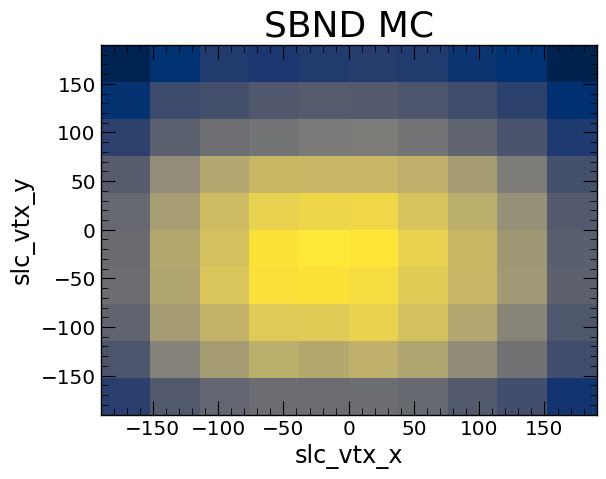

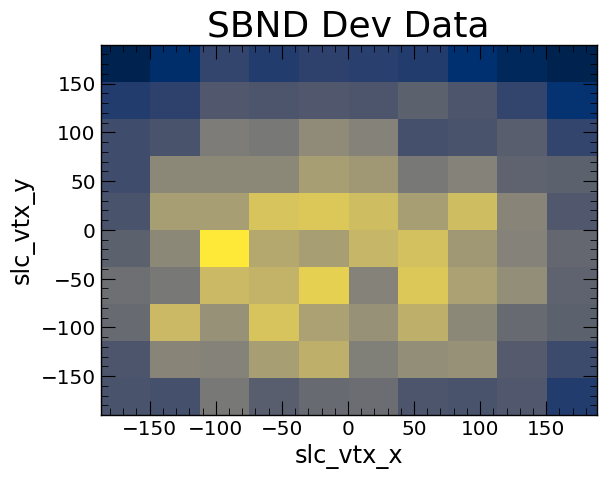

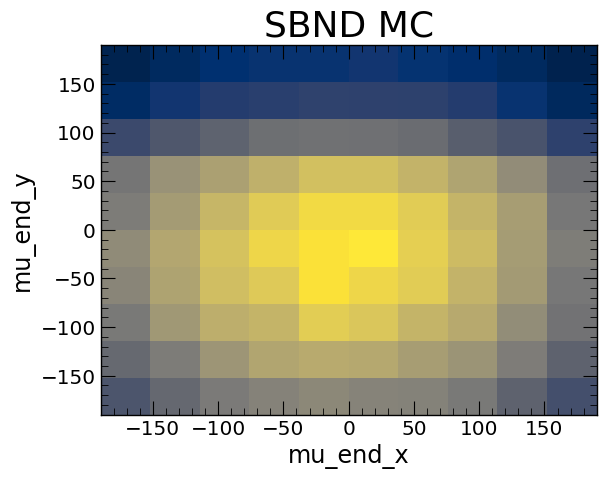

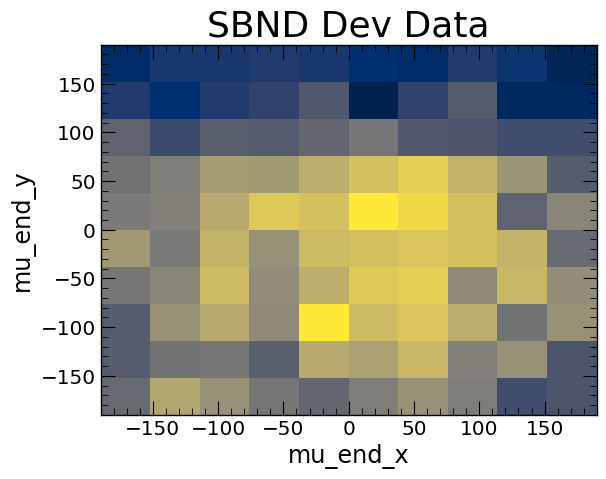

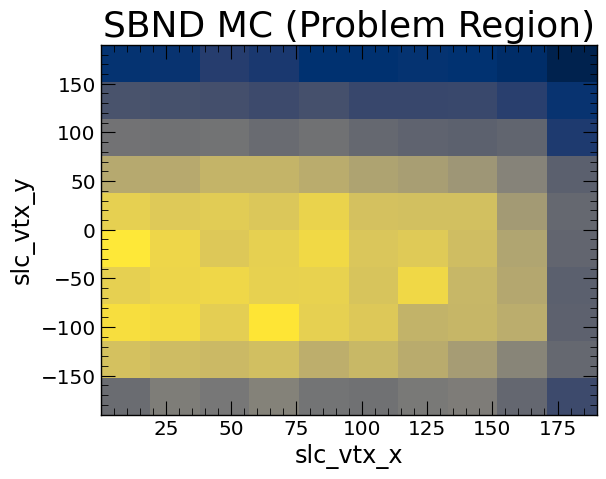

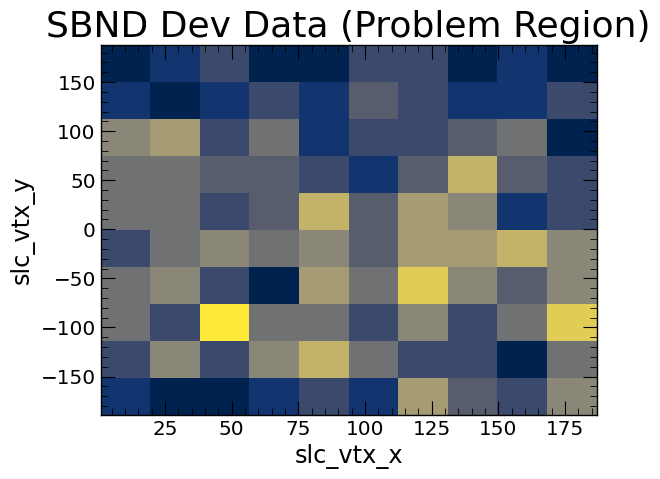

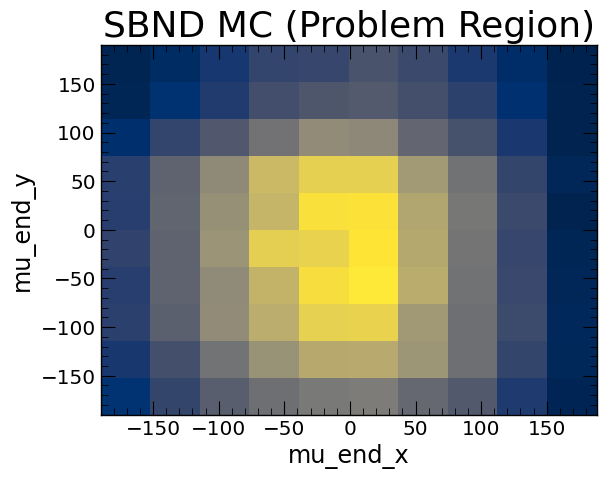

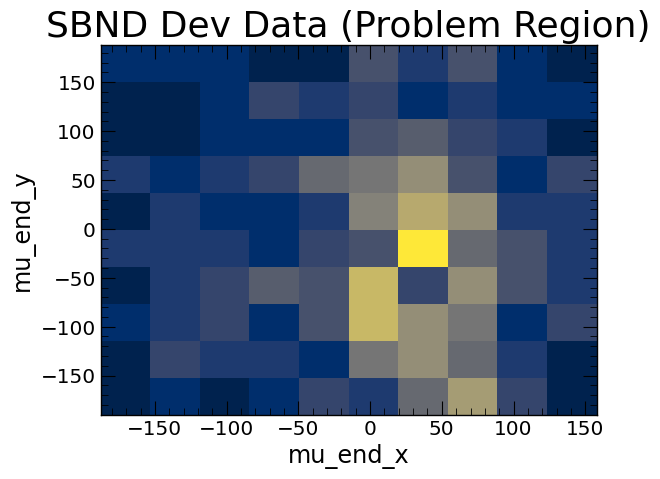

<Figure size 640x480 with 0 Axes>

In [28]:
plt.hist2d(recodf['slc_vtx_x'], recodf['slc_vtx_y'], bins=10)
plt.title('SBND MC')
plt.ylabel("slc_vtx_y")
plt.xlabel("slc_vtx_x")
plt.show()
plt.clf()

plt.hist2d(data_df['slc_vtx_x'], data_df['slc_vtx_y'], bins=10)
plt.title('SBND Dev Data')
plt.ylabel("slc_vtx_y")
plt.xlabel("slc_vtx_x")
plt.show()
plt.clf()

plt.hist2d(recodf['mu_end_x'], recodf['mu_end_y'], bins=10)
plt.title('SBND MC')
plt.ylabel("mu_end_y")
plt.xlabel("mu_end_x")
plt.show()
plt.clf()

plt.hist2d(data_df['mu_end_x'], data_df['mu_end_y'], bins=10)
plt.title('SBND Dev Data')
plt.ylabel("mu_end_y")
plt.xlabel("mu_end_x")
plt.show()
plt.clf()

recodf_temp = recodf[(recodf.mu_phi < -50.) & (recodf.mu_phi > -120.) & (recodf.slc_vtx_x > 0.)]
data_df_temp = data_df[(data_df.mu_phi < -50.) & (data_df.mu_phi > -120.) & (data_df.slc_vtx_x > 0.)]

plt.hist2d(recodf_temp['slc_vtx_x'], recodf_temp['slc_vtx_y'], bins=10)
plt.title('SBND MC (Problem Region)')
plt.ylabel("slc_vtx_y")
plt.xlabel("slc_vtx_x")
plt.show()
plt.clf()

plt.hist2d(data_df_temp['slc_vtx_x'], data_df_temp['slc_vtx_y'], bins=10)
plt.title('SBND Dev Data (Problem Region)')
plt.ylabel("slc_vtx_y")
plt.xlabel("slc_vtx_x")
plt.show()
plt.clf()

plt.hist2d(recodf_temp['mu_end_x'], recodf_temp['mu_end_y'], bins=10)
plt.title('SBND MC (Problem Region)')
plt.ylabel("mu_end_y")
plt.xlabel("mu_end_x")
plt.show()
plt.clf()

plt.hist2d(data_df_temp['mu_end_x'], data_df_temp['mu_end_y'], bins=10)
plt.title('SBND Dev Data (Problem Region)')
plt.ylabel("mu_end_y")
plt.xlabel("mu_end_x")
plt.show()
plt.clf()